## SF: Feature Engineering

**Goal:** Transform raw features into a richer, model-ready dataset that gives our
machine learning models the best possible signal for Sales Forecasting


Importing Necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import holidays
warnings.filterwarnings("ignore")

## Load Dataset/Dataset Overview

In [2]:
# Load the cleaned 
df = pd.read_csv(r"c:\Users\HP USER\Desktop\sales_forecasting\data\Processed.csv")
df_features = df.copy()
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")

df["Order Date"] = pd.to_datetime(df['Order Date'])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

df.head()

Shape: (9800, 21)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Year', 'Month', 'Day']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Day
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,8
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,8
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,12
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,11
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,11


## 1. Forecasting Grain

In [3]:
# Aggregate to monthly total sales
ts = df.set_index('Order Date').resample('M')['Sales'].sum().reset_index()
ts.columns = ['Date', 'Sales']
ts.head()

,Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [4]:
ts.shape

(48, 2)

Aggregating to monthly total sales because the sales forecasting will be built on monthly sales 

## 2. Calender/Date Based features  

In [5]:
ts['Year'] = ts['Date'].dt.year
ts['Month'] = ts['Date'].dt.month
ts['Quarter'] = ts['Date'].dt.quarter
ts['MonthName'] = ts['Date'].dt.month_name()

# Cyclical encoding for month (captures that Dec is "close to" Jan)
ts['Month_sin'] = np.sin(2 * np.pi * ts['Month']/12)
ts['Month_cos'] = np.cos(2 * np.pi * ts['Month']/12)

Cyclical Encoding(Month_sin/Month_cos) was used because using raw month(January(1)-December(12)) might confuse tree/linear models into concluding December(12) and January(1) are quite far apart when one actually comes after another. So cyclical encoding captures that December is "close to" January

## 3.Lag features (past sales as predictors)

In [6]:
for lag in [1, 2, 3, 12]:  # 1, 2, 3 months back, and same month last year
    ts[f'Sales_lag_{lag}'] = ts['Sales'].shift(lag)

ts[['Date','Sales','Sales_lag_1','Sales_lag_12']].tail(10)

,Date,Sales,Sales_lag_1,Sales_lag_12
38,2018-03-31,58863.4128,19920.9974,51165.0590
39,2018-04-30,35541.9101,58863.4128,38679.7670
40,2018-05-31,43825.9822,35541.9101,56656.9080
41,2018-06-30,48190.7277,43825.9822,39724.4860
42,2018-07-31,44825.1040,48190.7277,38320.7830
43,2018-08-31,62837.8480,44825.1040,30542.2003
44,2018-09-30,86152.8880,62837.8480,69193.3909
45,2018-10-31,77448.1312,86152.8880,59583.0330
46,2018-11-30,117938.1550,77448.1312,79066.4958
47,2018-12-31,83030.3888,117938.1550,95739.1210


Sales_lag_1 captures short-term momentum. Sales_lag_12 is important because the data has clear yearly seasonality (November/December) peaks. It tells the model "what happened this same month last year."

Introducing this feature will cause the first 12 rows to have null values(NaNs), it will be handled later in the notebook. 

## 4. Rolling Windows Features 

In [7]:
ts['Rolling_mean_3'] = ts['Sales'].shift(1).rolling(window=3).mean()
ts['Rolling_std_3'] = ts['Sales'].shift(1).rolling(window=3).std()
ts['Rolling_mean_6'] = ts['Sales'].shift(1).rolling(window=6).mean()

Rolling-window features capture the recent level, trend, and volatility of sales, providing the model with information about short-term sales behaviour that individual lag values may not capture. This can improve the model's ability to predict future demand and adapt to changing sales patterns.

## 5. Growth/change features

In [8]:
ts['Pct_change_1'] = ts['Sales'].pct_change(1)
ts['Diff_1'] = ts['Sales'].diff(1)


Growth/change features is useful for noticing momentum shifts,if sales is accelerating,decelerating of flat.


### 6. Holiday features

In [9]:
# pip install holidays --break-system-packages  
import holidays

us_holidays = holidays.US(years=[2015, 2016, 2017, 2018])

# Build a set of (year, month) pairs that contain at least one US holiday
holiday_year_months = {(d.year, d.month) for d in us_holidays}

ts['IsHoliday'] = ts['Date'].apply(
    lambda d: int((d.year, d.month) in holiday_year_months)
).astype(int)

# quick check of the effect
print(ts.groupby('IsHoliday')['Sales'].mean())
print(ts['IsHoliday'].value_counts())

IsHoliday
0    39813.127381
1    50766.460769
Name: Sales, dtype: float64
IsHoliday
1    32
0    16
Name: count, dtype: int64


## 6. Handle NaNs created by lag/rolling features

In [10]:
ts_m = ts.dropna().reset_index(drop=True)
print(ts.shape, '->', ts_m.shape)

(48, 18) -> (36, 18)


## 8.Final feature set check

In [11]:
print(ts_m.columns.tolist())
ts_m.head()

['Date', 'Sales', 'Year', 'Month', 'Quarter', 'MonthName', 'Month_sin', 'Month_cos', 'Sales_lag_1', 'Sales_lag_2', 'Sales_lag_3', 'Sales_lag_12', 'Rolling_mean_3', 'Rolling_std_3', 'Rolling_mean_6', 'Pct_change_1', 'Diff_1', 'IsHoliday']


,Date,Sales,Year,Month,Quarter,MonthName,Month_sin,Month_cos,Sales_lag_1,Sales_lag_2,Sales_lag_3,Sales_lag_12,Rolling_mean_3,Rolling_std_3,Rolling_mean_6,Pct_change_1,Diff_1,IsHoliday
0,2016-01-31,18066.9576,2016,1,1,January,0.500000,8.660254e-01,68167.0585,77907.6607,31453.3930,14205.707,59176.037400,24497.522165,53341.786417,-0.734961,-50100.1009,1
1,2016-02-29,11951.4110,2016,2,1,February,0.866025,5.000000e-01,18066.9576,68167.0585,77907.6607,4519.892,54713.892267,32108.693498,50722.688850,-0.338493,-6115.5466,1
2,2016-03-31,32339.3184,2016,3,1,March,1.000000,6.123234e-17,11951.4110,18066.9576,68167.0585,55205.797,32728.475700,30842.662672,48195.001267,1.705900,20387.9074,0
3,2016-04-30,34154.4685,2016,4,2,April,0.866025,-5.000000e-01,32339.3184,11951.4110,18066.9576,27906.855,20785.895667,10462.368766,39980.966533,0.056128,1815.1501,0
4,2016-05-31,29959.5305,2016,5,2,May,0.500000,-8.660254e-01,34154.4685,32339.3184,11951.4110,23644.303,26148.399300,12328.404198,40431.145783,-0.122823,-4194.9380,1


In [12]:
ts_m.to_csv("sf_new_features.csv", index=False)
print('\n Saved →sf_new_features.csv')


 Saved →sf_new_features.csv


# Time-series/statistical analysis


In [13]:
ts = df.set_index('Order Date').resample('M')['Sales'].sum()
ts.head()

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

### Augmented Dickey-Fuller (ADF):

In [14]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, title=''):
    result = adfuller(series.dropna())
    print(f'ADF Test: {title}')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print('Critical Values:')
    for key, val in result[4].items():
        print(f'   {key}: {val:.4f}')
    if result[1] <= 0.05:
        print('=> Reject H0: Series is stationary\n')
    else:
        print('=> Fail to reject H0: Series is NON-stationary\n')

adf_test(ts, 'Monthly Sales')

ADF Test: Monthly Sales
ADF Statistic: -4.4161
p-value: 0.0003
Critical Values:
   1%: -3.5778
   5%: -2.9253
   10%: -2.6008
=> Reject H0: Series is stationary



Result: ADF statistic = -4.4161, p-value = 0.0003 below 0.05, rejecting  H0 
The conclusion printed: "Series is stationary."

The Augmented Dickey-Fuller (ADF) test was performed to check the stationarity of the monthly sales series.It produced an ADF statistic of -4.4161 and a p-value of 0.0003. Since the p-value is significantly lower than the 5% significance level (0.05), the null hypothesis of a unit root is rejected. Furthermore, the ADF statistic is more negative than the critical values at the 1%, 5%, and 10% significance levels. Therefore, the monthly sales series is stationary.

KPSS test, second opinion (opposite null hypothesis): used to get another opinion to confirm if the time series is stationary or non-stationary

In [15]:
from statsmodels.tsa.stattools import kpss

def kpss_test(series, title=''):
    result = kpss(series.dropna(), regression='c', nlags='auto')
    print(f'KPSS Test: {title}')
    print(f'KPSS Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    if result[1] < 0.05:
        print('=> Reject H0: Series is NON-stationary\n')
    else:
        print('=> Fail to reject H0: Series is stationary\n')

kpss_test(ts, 'Monthly Sales')

KPSS Test: Monthly Sales
KPSS Statistic: 0.6293
p-value: 0.0200
=> Reject H0: Series is NON-stationary



The KPSS test was performed to assess the stationarity of the monthly sales series. The test produced a KPSS statistic of 0.6293 and a p-value of 0.0200. Since the p-value is below the 5% significance level, the null hypothesis that the series is stationary is rejected. Therefore, the monthly sales series is considered non-stationary, indicating that its underlying statistical properties vary over time.

Conclusion:
The ADF test rejects the null hypothesis of a unit root, suggesting that the series is stationary. However, the KPSS test rejects its null hypothesis of stationarity, indicating evidence of non-stationarity. Since the two tests provide different results, stationarity cannot be conclusively established from these tests alone. This concludes that the series is trend stationary.

## Time series decomposition

This splits the series into Trend, Seasonal, and Residual components visually confirms the output of ADF/KPSS numerically.

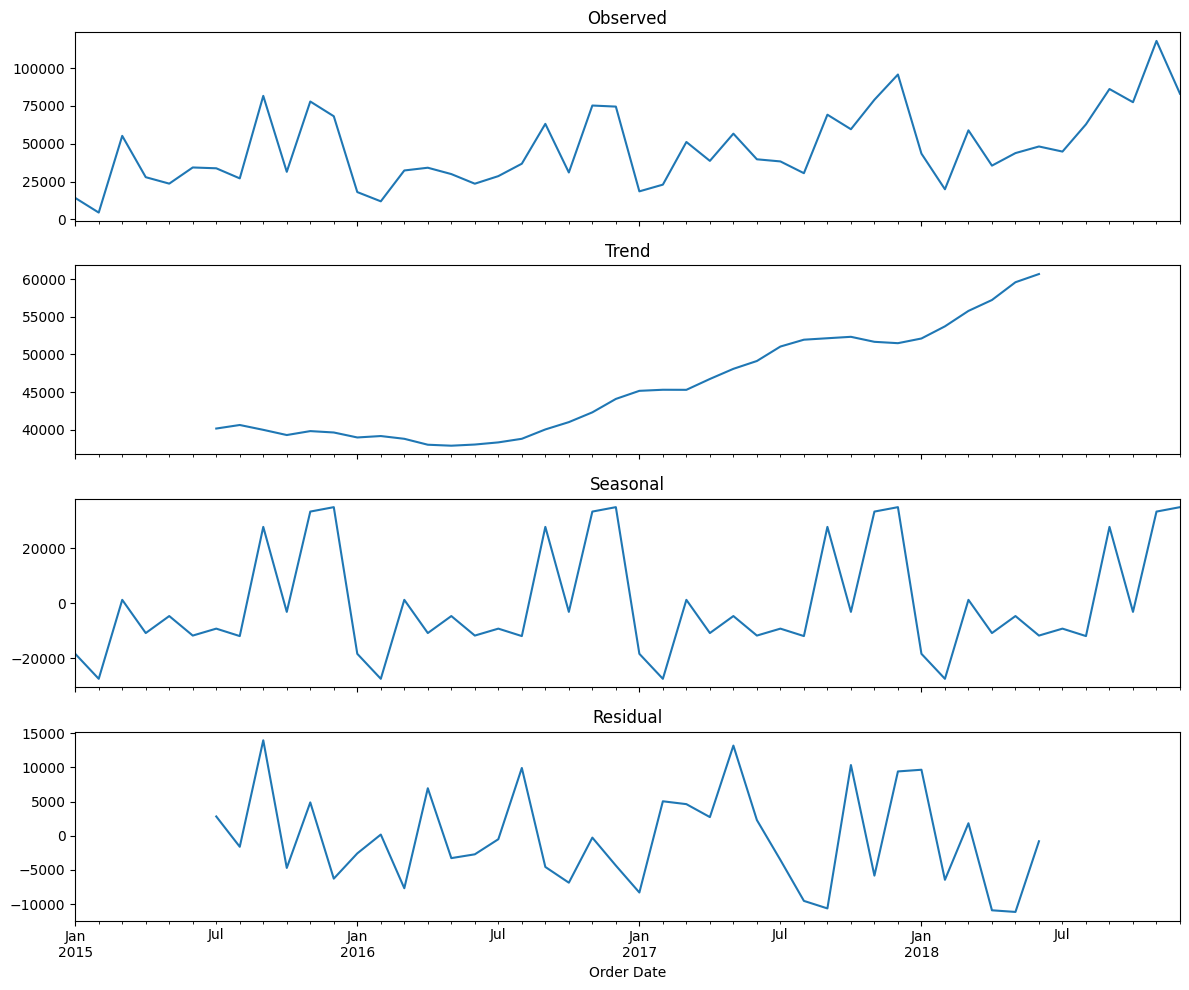

In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(ts, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal')
decomposition.resid.plot(ax=axes[3], title='Residual')
plt.tight_layout()
plt.show()

Same as the EDA, noisy month-to-month, ranging roughly $5K–$115K, with an overall climb by 2018
Trend: starts flat around $40K (2015–2016), dips slightly in early 2016, then climbs steadily from mid-2016 to over $60K by late 2018. This is the real underlying growth signal once seasonal noise is stripped out
Seasonal: a clean repeating wave, identical every year, big troughs around Jan/Feb (roughly -$20K to -$25K below trend) and sharp peaks mid/late year (up to +$24K). This confirms the Nov/Dec and March seasonality found in the EDA, now isolated and quantified.
Residual: bounces between roughly -$11K and +$14K with no obvious remaining pattern, looks like reasonable noise, meaning trend+seasonal(12) is capturing most of the structure

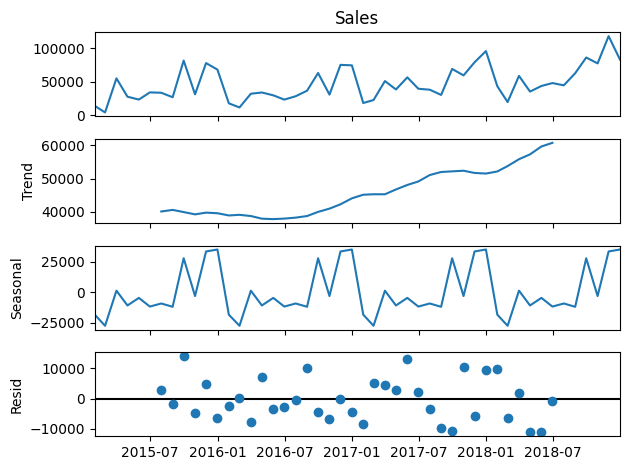

In [17]:
decomposition_mult = seasonal_decompose(ts, model='additive', period=12)
decomposition_mult.plot()
plt.show()

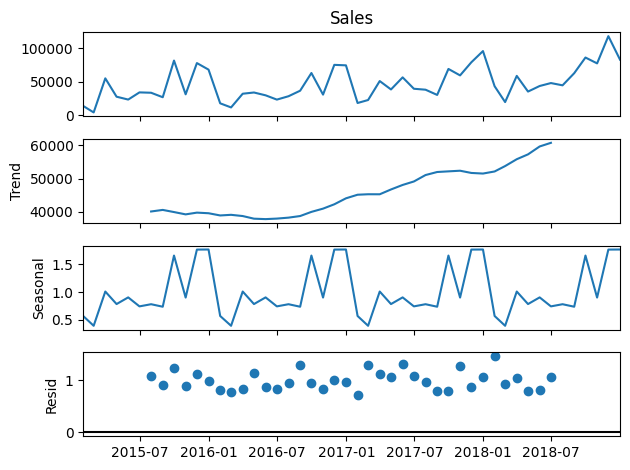

In [18]:
decomposition_mult = seasonal_decompose(ts, model='multiplicative', period=12)
decomposition_mult.plot()
plt.show()

Multiplicative decomposition
Trend: same shape as additive (flat then rising)
Seasonal: now expressed as a ratio around 1.0, troughs down to ~0.4-0.5 (sales fall to 40-50% of trend in low months) and peaks up to ~1.7 (70% above trend in strong months)
Residual: hovers around 1.0, scattered between roughly 0.6 and 1.3

Since the residuals in both versions look similarly noise-like (no leftover pattern), and the seasonal swings didn't visibly grow much in absolute size as the trend rose, additive is a defensible choice  but multiplicative is worth keeping.

## First Order Differencing

Differencing (because the ARIMA/SARIMA model will be trained later)

ADF Test: First-Differenced Sales
ADF Statistic: -8.7271
p-value: 0.0000
Critical Values:
   1%: -3.6267
   5%: -2.9460
   10%: -2.6117
=> Reject H0: Series is stationary



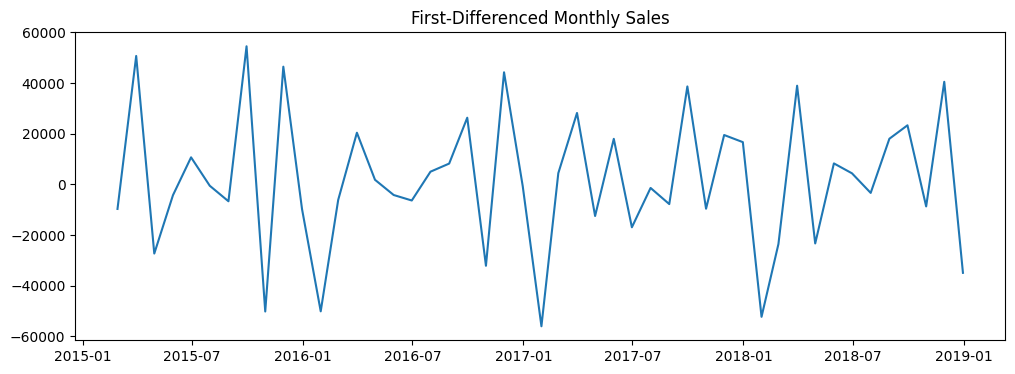

In [19]:
ts_diff = ts.diff().dropna()
adf_test(ts_diff, 'First-Differenced Sales')

plt.figure(figsize=(12,4))
plt.plot(ts_diff)
plt.title('First-Differenced Monthly Sales')
plt.show()

Result: ADF statistic = -8.7271, p-value ≈ 0.0000 → strongly stationary.

The differenced series (month-over-month change in sales) swings between about -$56K and +$55K with no visible trend left. It oscillates around zero, which is exactly what a stationary series should look like. This confirms d=1 is more than sufficient.

ACF/PACF on the differenced series

ACF/PACF plots gives details about the ARIMA order.

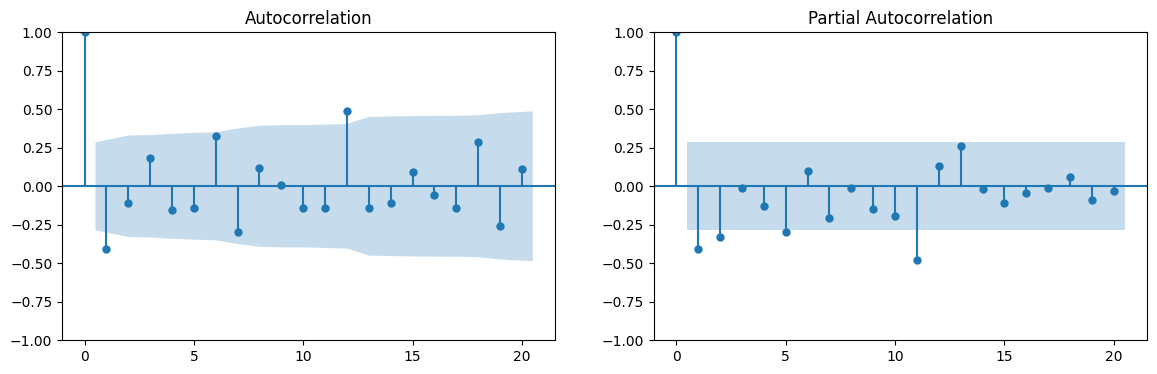

In [20]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14,4))
plot_acf(ts_diff, ax=axes[0], lags=20)
plot_pacf(ts_diff, ax=axes[1], lags=20)
plt.show()

ACF (left): a strong negative spike at lag 1 (~-0.42), then a notably significant positive spike at lag 12 (~0.49, clearly outside the confidence band), this is the seasonal signature reappearing even after differencing.
PACF (right): significant negative spikes at lag 1 and lag 2, and a strong negative spike at lag 11 (~-0.47), with a positive spike around lag 13.
The lag-12 spike in the ACF is the key finding. It shows the yearly seasonality survives differencing.